
Total observations after cleaning: 11611
Observations per city:
 city
London         4435
Delhi          4244
Mexico City    2932
Name: count, dtype: int64 



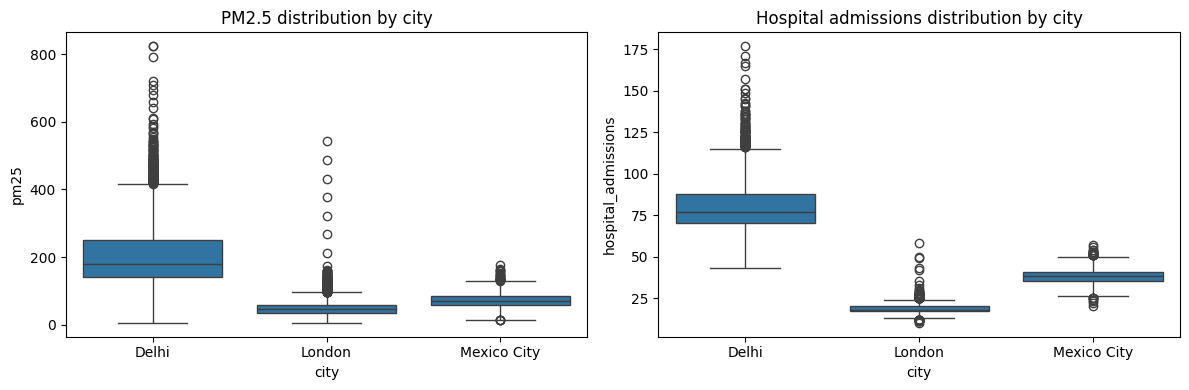

Kruskal-Wallis results:
PM2.5: H = 8123.2731, p = 0.0000000000
Admissions: H = 10205.1203, p = 0.0000000000

--- Pairwise Mann-Whitney for PM2.5 ---
Number of pairwise comparisons: 3
Bonferroni‑corrected alpha = 0.016667

Delhi vs London: p = 0.0000000000, Significant after Bonferroni = True
Delhi vs Mexico City: p = 0.0000000000, Significant after Bonferroni = True
London vs Mexico City: p = 0.0000000000, Significant after Bonferroni = True

--- Pairwise Mann-Whitney for Hospital Admissions ---
Number of pairwise comparisons: 3
Bonferroni‑corrected alpha = 0.016667

Delhi vs London: p = 0.0000000000, Significant after Bonferroni = True
Delhi vs Mexico City: p = 0.0000000000, Significant after Bonferroni = True
London vs Mexico City: p = 0.0000000000, Significant after Bonferroni = True


In [1]:
# ===================================================================
# INFERENTIAL STATISTICS FOR THREE CITIES (Delhi, London, Mexico City)
# ===================================================================
# Purpose: Compare PM2.5 levels and hospital admissions among three cities
# Methods: Kruskal-Wallis test (overall difference) + Mann-Whitney pairwise
#           with Bonferroni correction (to control Type I error)
# ===================================================================

import pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------
# The merged CSV file must contain columns: city, pm25, hospital_admissions
# Set the correct filename below. The script should be in the same folder.
filename = 'merged_project_data.csv'   # <-- CHANGE TO YOUR ACTUAL FILE NAME
df = pd.read_csv(filename)

# -------------------------------------------------------------------
# 2. SPECIFY COLUMN NAMES (adjust if your dataset uses different names)
# -------------------------------------------------------------------
city_col = 'city'
pm25_col = 'pm25'
admission_col = 'hospital_admissions'

# -------------------------------------------------------------------
# 3. CLEAN DATA: keep only needed columns, remove rows with missing values
# -------------------------------------------------------------------
df_clean = df[[city_col, pm25_col, admission_col]].dropna()
print(f"\nTotal observations after cleaning: {len(df_clean)}")
print("Observations per city:\n", df_clean[city_col].value_counts(), "\n")

# -------------------------------------------------------------------
# 4. VISUALIZE DISTRIBUTIONS (boxplots)
#    – This helps to see whether assumptions for ANOVA are met
#    – If distributions are skewed or have outliers, non‑parametric tests are needed
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_clean, x=city_col, y=pm25_col, ax=axes[0])
axes[0].set_title('PM2.5 distribution by city')
sns.boxplot(data=df_clean, x=city_col, y=admission_col, ax=axes[1])
axes[1].set_title('Hospital admissions distribution by city')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 5. KRUSKAL-WALLIS TEST (non‑parametric alternative to one‑way ANOVA)
#    – Why not ANOVA? Because our data are not normally distributed 
#      (Shapiro–Wilk p < 0.001) and variances are not homogeneous.
#    – H0: All three cities have the same distribution.
#    – H1: At least one city differs.
# -------------------------------------------------------------------
cities = df_clean[city_col].unique()

# Create lists of values for each city
groups_pm25 = [df_clean[df_clean[city_col]==c][pm25_col].values for c in cities]
groups_adm  = [df_clean[df_clean[city_col]==c][admission_col].values for c in cities]

# Perform the Kruskal-Wallis test
h_pm25, p_pm25 = kruskal(*groups_pm25)
h_adm,  p_adm  = kruskal(*groups_adm)

print("Kruskal-Wallis results:")
print(f"PM2.5: H = {h_pm25:.4f}, p = {p_pm25:.10f}")
print(f"Admissions: H = {h_adm:.4f}, p = {p_adm:.10f}\n")
# If p < 0.05, we reject H0 and conclude that there is a significant overall difference.

# -------------------------------------------------------------------
# 6. PAIRWISE MANN‑WHITNEY U TESTS WITH BONFERRONI CORRECTION
#    – After Kruskal-Wallis, we need to know which specific pairs differ.
#    – We use Mann-Whitney for each pair (e.g., Delhi vs London).
#    – Since we do 3 comparisons, we adjust the significance level 
#      to control the family‑wise error rate: α_bonferroni = 0.05 / 3 = 0.0167
# -------------------------------------------------------------------
def pairwise_mannwhitney(data, value_col, group_col):
    """Perform Mann-Whitney tests for all pairs of groups,
       applying Bonferroni correction."""
    groups = data[group_col].unique()
    comparisons = list(combinations(groups, 2))
    n_comp = len(comparisons)
    bonferroni_alpha = 0.05 / n_comp
    print(f"Number of pairwise comparisons: {n_comp}")
    print(f"Bonferroni‑corrected alpha = {bonferroni_alpha:.6f}\n")
    for c1, c2 in comparisons:
        sample1 = data[data[group_col]==c1][value_col]
        sample2 = data[data[group_col]==c2][value_col]
        u, p = mannwhitneyu(sample1, sample2, alternative='two-sided')
        reject = p < bonferroni_alpha
        print(f"{c1} vs {c2}: p = {p:.10f}, Significant after Bonferroni = {reject}")
    # Note: The U statistic is omitted here because p‑value is the key decision criterion.

# Run pairwise tests for PM2.5
print("--- Pairwise Mann-Whitney for PM2.5 ---")
pairwise_mannwhitney(df_clean, pm25_col, city_col)

# Run pairwise tests for hospital admissions
print("\n--- Pairwise Mann-Whitney for Hospital Admissions ---")
pairwise_mannwhitney(df_clean, admission_col, city_col)